# CS224N Assignment 1: Exploring Word Vectors (25 Points)
### <font color='blue'> Due 4:30pm, Tue January 13th 2026</font>

Welcome to CS224N! 

Before you start, make sure you **read the README.md** in the same directory as this notebook for important setup information. You need to install some Python libraries before you can successfully do this assignment. A lot of code is provided in this notebook, and we highly encourage you to read and understand it as part of the learning :)

If you aren't super familiar with Python, Numpy, or Matplotlib, we recommend you check out the review session on Friday. The session will be recorded and the material will be made available on our [website](http://web.stanford.edu/class/cs224n/index.html#schedule). The CS231N Python/Numpy [tutorial](https://cs231n.github.io/python-numpy-tutorial/) is also a great resource.


**Assignment Notes:** Please make sure to save the notebook as you go along. Submission Instructions are located at the bottom of the notebook.

# CS224N 作业 1：探索词向量（25 分）
### <font color='blue'> 截止时间：2026年1月13日星期二下午4:30</font>

欢迎来到 CS224N！

在开始之前，请确保您已阅读与此笔记本同一目录下的 **README.md**，其中包含重要的设置信息。在成功完成此作业之前，您需要安装一些 Python 库。这个笔记本中提供了大量的代码，我们强烈建议您阅读并理解这些代码，作为学习的一部分 :)。

如果您对 Python、Numpy 或 Matplotlib 不够熟悉，我们建议您参加星期五的复习课程。该课程将进行录音，并在我们的 [网站](http://web.stanford.edu/class/cs224n/index.html#schedule) 上提供材料。CS231N 的 Python/Numpy [教程](https://cs231n.github.io/python-numpy-tutorial/) 也是一份很好的资源。


**作业说明：** 请确保在作业过程中保存笔记本。提交说明位于笔记本底部。

In [1]:
# All Import Statements Defined Here
# Note: Do not add to this list.
# ----------------

import sys
assert sys.version_info[0] == 3
assert sys.version_info[1] >= 8

from platform import python_version
assert int(python_version().split(".")[1]) >= 5, "Please upgrade your Python version following the instructions in \
    the README.md file found in the same directory as this notebook. Your Python version is " + python_version()

from gensim.models import KeyedVectors
from gensim.test.utils import datapath
import pprint
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 5]

from datasets import load_dataset
imdb_dataset = load_dataset("stanfordnlp/imdb", name="plain_text")

import re
import numpy as np
import random
import scipy as sp
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA

START_TOKEN = '<START>'
END_TOKEN = '<END>'
NUM_SAMPLES = 150

np.random.seed(0)
random.seed(0)
# ----------------

## Word Vectors

Word Vectors are often used as a fundamental component for downstream NLP tasks, e.g. question answering, text generation, translation, etc., so it is important to build some intuitions as to their strengths and weaknesses. Here, you will explore two types of word vectors: those derived from *co-occurrence matrices*, and those derived via *GloVe*. 

**Note on Terminology:** The terms "word vectors" and "word embeddings" are often used interchangeably. The term "embedding" refers to the fact that we are encoding aspects of a word's meaning in a lower dimensional space. As [Wikipedia](https://en.wikipedia.org/wiki/Word_embedding) states, "*conceptually it involves a mathematical embedding from a space with one dimension per word to a continuous vector space with a much lower dimension*".

## 词向量

词向量常被用作下游自然语言处理任务（例如问答、文本生成、翻译等）的基本组成部分，因此了解它们的优缺点是很重要的。在这里，你将探索两种类型的词向量：一种是从**共现矩阵**中派生出来的，另一种是通过**GloVe**派生出来的。

**术语说明：**“词向量”和“词嵌入”这两个术语经常可以互换使用。术语“嵌入”指的是我们将词的意义的某些方面编码在一个低维空间中。正如维基百科[所描述的](https://en.wikipedia.org/wiki/Word_embedding)，“从每个词有一个维度的空间到具有许多更低维度的连续向量空间的概念上涉及数学嵌入”。

## Part 1: Count-Based Word Vectors (10 points)

Most word vector models start from the following idea:

*You shall know a word by the company it keeps ([Firth, J. R. 1957:11](https://en.wikipedia.org/wiki/John_Rupert_Firth))*

Many word vector implementations are driven by the idea that similar words, i.e., (near) synonyms, will be used in similar contexts. As a result, similar words will often be spoken or written along with a shared subset of words, i.e., contexts. By examining these contexts, we can try to develop embeddings for our words. With this intuition in mind, many "old school" approaches to constructing word vectors relied on word counts. Here we elaborate upon one of those strategies, *co-occurrence matrices* (for more information, see [here](https://web.stanford.edu/~jurafsky/slp3/6.pdf) or [here](https://web.archive.org/web/20190530091127/https://medium.com/data-science-group-iitr/word-embedding-2d05d270b285)).

## 第1部分：基于计数的词向量（10分）

大多数词向量模型都基于以下想法：

*“通过其相伴之物认识一个词”（[Firth, J. R. 1957:11](https://en.wikipedia.org/wiki/John_Rupert_Firth)*）

许多词向量实现都受到这样一个观点的驱动：相似词语，即（近）同义词，会在相似语境中使用。因此，相似词语通常会与一个共享的词子集（即语境）一起被说出或写出。通过考察这些语境，我们可以尝试为我们的词语开发嵌入。带着这种直觉，许多“传统”构建词向量的方法依赖于词计数。在此，我们详细阐述其中一种策略，即**共现矩阵**（更多信息请参阅[这里](https://web.stanford.edu/~jurafsky/slp3/6.pdf)或[这里](https://web.archive.org/web/20190530091127/https://medium.com/data-science-group-iitr/word-embedding-2d05d270b285))。

### Co-Occurrence

A co-occurrence matrix counts how often things co-occur in some environment. Given some word $w_i$ occurring in the document, we consider the *context window* surrounding $w_i$. Supposing our fixed window size is $n$, then this is the $n$ preceding and $n$ subsequent words in that document, i.e. words $w_{i-n} \dots w_{i-1}$ and $w_{i+1} \dots w_{i+n}$. We build a *co-occurrence matrix* $M$, which is a symmetric word-by-word matrix in which $M_{ij}$ is the number of times $w_j$ appears inside $w_i$'s window among all documents.

**Example: Co-Occurrence with Fixed Window of n=1**:

Document 1: "all that glitters is not gold"

Document 2: "all is well that ends well"


|     *    | `<START>` | all | that | glitters | is   | not  | gold  | well | ends | `<END>` |
|----------|-------|-----|------|----------|------|------|-------|------|------|-----|
| `<START>`    | 0     | 2   | 0    | 0        | 0    | 0    | 0     | 0    | 0    | 0   |
| all      | 2     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 0    | 0   |
| that     | 0     | 1   | 0    | 1        | 0    | 0    | 0     | 1    | 1    | 0   |
| glitters | 0     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 0    | 0   |
| is       | 0     | 1   | 0    | 1        | 0    | 1    | 0     | 1    | 0    | 0   |
| not      | 0     | 0   | 0    | 0        | 1    | 0    | 1     | 0    | 0    | 0   |
| gold     | 0     | 0   | 0    | 0        | 0    | 1    | 0     | 0    | 0    | 1   |
| well     | 0     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 1    | 1   |
| ends     | 0     | 0   | 1    | 0        | 0    | 0    | 0     | 1    | 0    | 0   |
| `<END>`      | 0     | 0   | 0    | 0        | 0    | 0    | 1     | 1    | 0    | 0   |

In NLP, we commonly use `<START>` and `<END>` tokens to mark the beginning and end of sentences, paragraphs, or documents. These tokens are included in co-occurrence counts, encapsulating each document, for example: "`<START>` All that glitters is not gold `<END>`".

The matrix rows (or columns) provide word vectors based on word-word co-occurrence, but they can be large. To reduce dimensionality, we employ Singular Value Decomposition (SVD), akin to PCA, selecting the top $k$ principal components. The SVD process decomposes the co-occurrence matrix $A$ into singular values in the diagonal $S$ matrix and new, shorter word vectors in $U_k$.

This dimensionality reduction maintains semantic relationships; for instance, *doctor* and *hospital* will be closer than *doctor* and *dog*.

For those unfamiliar with eigenvalues and SVD, a beginner-friendly introduction to SVD is available [here](https://davetang.org/file/Singular_Value_Decomposition_Tutorial.pdf). Additional resources for in-depth understanding include lectures [7](https://web.stanford.edu/class/cs168/l/l7.pdf), [8](http://theory.stanford.edu/~tim/s15/l/l8.pdf), and [9](https://web.stanford.edu/class/cs168/l/l9.pdf) of CS168, providing high-level treatment of these algorithms. For practical implementation, utilizing pre-programmed functions from Python packages like numpy, scipy, or sklearn is recommended. While applying full SVD to large corpora can be memory-intensive, scalable techniques such as Truncated SVD exist for extracting the top $k$ vector components efficiently.

### 共现

共现矩阵计算在某个环境中事物共现的频率。给定文档中出现的某个词 $w_i$，我们考虑其周围的 *上下文窗口*。假设我们的固定窗口大小为 $n$，那么这指的是文档中 $w_i$ 前后的 $n$ 个词，即 $w_{i-n} \dots w_{i-1}$ 和 $w_{i+1} \dots w_{i+n}$。我们构建一个 *共现矩阵* $M$，它是一个对称的词对词矩阵，其中 $M_{ij}$ 是 $w_j$ 在所有文档中出现在 $w_i$ 窗口内的次数。

**示例：n=1 的固定窗口共现**：

文档 1: "all that glitters is not gold"

文档 2: "all is well that ends well"


|     *    | `<START>` | all | that | glitters | is   | not  | gold  | well | ends | `<END>` |
|----------|-------|-----|------|----------|------|------|-------|------|------|-----|
| `<START>`    | 0     | 2   | 0    | 0        | 0    | 0    | 0     | 0    | 0    | 0   |
| all      | 2     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 0    | 0   |
| that     | 0     | 1   | 0    | 1        | 0    | 0    | 0     | 1    | 1    | 0   |
| glitters | 0     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 0    | 0   |
| is       | 0     | 1   | 0    | 1        | 0    | 1    | 0     | 1    | 0    | 0   |
| not      | 0     | 0   | 0    | 0        | 1    | 0    | 1     | 0    | 0    | 0   |
| gold     | 0     | 0   | 0    | 0        | 0    | 1    | 0     | 0    | 0    | 1   |
| well     | 0     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 1    | 1   |
| ends     | 0     | 0   | 1    | 0        | 0    | 0    | 0     | 1    | 0    | 0   |
| `<END>`      | 0     | 0   | 0    | 0        | 0    | 0    | 1     | 1    | 0    | 0   |

在自然语言处理中，我们通常使用 `<START>` 和 `<END>` 标记来标记句子、段落或文档的开始和结束。这些标记包含在共现计数中，封装每个文档，例如："`<START>` All that glitters is not gold `<END>`"。

矩阵的行（或列）提供了基于词-词共现的词向量，但它们可能很大。为了降低维度，我们采用类似于 PCA 的奇异值分解（SVD），选择前 $k$ 个主成分。SVD 过程将共现矩阵 $A$ 分解为对角矩阵 $S$ 中的奇异值和 $U_k$ 中的新、较短的词向量。

这种降维过程保持了语义关系；例如，*doctor* 和 *hospital* 将比 *doctor* 和 *dog* 更接近。
对于不熟悉特征值和奇异值分解（SVD）的人来说，这里有一个适合初学者的SVD介绍[在此](https://davetang.org/file/Singular_Value_Decomposition_Tutorial.pdf)。为了深入理解，还可以参考CS168课程中的讲座[7](https://web.stanford.edu/class/cs168/l/l7.pdf)、[8](http://theory.stanford.edu/~tim/s15/l/l8.pdf)和[9](https://web.stanford.edu/class/cs168/l/l9.pdf)，这些讲座对这些算法进行了高级别的讲解。对于实际应用，建议使用Python包如numpy、scipy或sklearn中的预编程函数。虽然将完整的SVD应用于大型语料库可能会消耗大量内存，但存在可扩展的技术，如截断奇异值分解（Truncated SVD），可以有效地提取前$k$个向量成分。

### Plotting Co-Occurrence Word Embeddings

Here, we will be using the Large Movie Review Dataset. This is a dataset for binary sentiment classification containing substantially more data than previous benchmark datasets. We provide a set of 25,000 highly polar movie reviews for training, and 25,000 for testing. There is additional unlabeled data for use as well. We provide a `read_corpus` function below that pulls out the text of a movie review from the dataset. The function also adds `<START>` and `<END>` tokens to each of the documents, and lowercases words. You do **not** have to perform any other kind of pre-processing.

### 绘制共现词嵌入图

在此，我们将使用大型电影评论数据集。这是一个用于二元情感分类的数据集，包含比之前基准数据集多得多的数据。我们提供了25,000条高度极化的电影评论用于训练，以及25,000条用于测试。此外，我们还提供了额外的未标记数据供使用。下面提供了一个`read_corpus`函数，该函数可以从数据集中提取电影评论的文本。该函数还将`<START>`和`<END>`标记添加到每个文档中，并将单词转换为小写。您**不需要**进行任何其他类型的预处理。

In [2]:
def read_corpus():
    """ Read files from the Large Movie Review Dataset.
        Params:
            category (string): category name
        Return:
            list of lists, with words from each of the processed files
    """
    files = imdb_dataset["train"]["text"][:NUM_SAMPLES]
    return [[START_TOKEN] + [re.sub(r'[^\w]', '', w.lower()) for w in f.split(" ")] + [END_TOKEN] for f in files]

Let's have a look what these documents are like….

In [3]:
imdb_corpus = read_corpus()
pprint.pprint(imdb_corpus[:3], compact=True, width=100)
print("corpus size: ", len(imdb_corpus[0]))

[['<START>', 'i', 'rented', 'i', 'am', 'curiousyellow', 'from', 'my', 'video', 'store', 'because',
  'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first',
  'released', 'in', '1967', 'i', 'also', 'heard', 'that', 'at', 'first', 'it', 'was', 'seized',
  'by', 'us', 'customs', 'if', 'it', 'ever', 'tried', 'to', 'enter', 'this', 'country', 'therefore',
  'being', 'a', 'fan', 'of', 'films', 'considered', 'controversial', 'i', 'really', 'had', 'to',
  'see', 'this', 'for', 'myselfbr', 'br', 'the', 'plot', 'is', 'centered', 'around', 'a', 'young',
  'swedish', 'drama', 'student', 'named', 'lena', 'who', 'wants', 'to', 'learn', 'everything',
  'she', 'can', 'about', 'life', 'in', 'particular', 'she', 'wants', 'to', 'focus', 'her',
  'attentions', 'to', 'making', 'some', 'sort', 'of', 'documentary', 'on', 'what', 'the', 'average',
  'swede', 'thought', 'about', 'certain', 'political', 'issues', 'such', 'as', 'the', 'vietnam',
  'war', 'and', 'race', 'issu

### Question 1.1: Implement `distinct_words` [code] (2 points)

Write a method to work out the distinct words (word types) that occur in the corpus.

You can use `for` loops to process the input `corpus` (a list of list of strings), but try using Python list comprehensions (which are generally faster). In particular, [this](https://coderwall.com/p/rcmaea/flatten-a-list-of-lists-in-one-line-in-python) may be useful to flatten a list of lists. If you're not familiar with Python list comprehensions in general, here's [more information](https://python-3-patterns-idioms-test.readthedocs.io/en/latest/Comprehensions.html).

Your returned `corpus_words` should be sorted. You can use python's `sorted` function for this.

You may find it useful to use [Python sets](https://www.w3schools.com/python/python_sets.asp) to remove duplicate words.

### 问题 1.1: 实现 `distinct_words` 方法 [代码]（2 分）

编写一个方法来找出语料库中出现的不同单词（单词类型）。

你可以使用 `for` 循环来处理输入 `corpus`（一个字符串列表的列表），但尝试使用 Python 列表推导式（通常更快）。特别是，[这个链接](https://coderwall.com/p/rcmaea/flatten-a-list-of-lists-in-one-line-in-python)可能有助于一行代码展平列表中的列表。如果你对 Python 列表推导式不熟悉，这里有一些[更多信息](https://python-3-patterns-idioms-test.readthedocs.io/en/latest/Comprehensions.html)。

你返回的 `corpus_words` 应该是有序的。你可以使用 Python 的 `sorted` 函数来实现这一点。

你可能需要使用 [Python 集合](https://www.w3schools.com/python/python_sets.asp)来移除重复的单词。

In [4]:
def distinct_words(corpus):
    """ Determine a list of distinct words for the corpus.
        Params:
            corpus (list of list of strings): corpus of documents
        Return:
            corpus_words (list of strings): sorted list of distinct words across the corpus
            n_corpus_words (integer): number of distinct words across the corpus
    """
    corpus_words = []
    n_corpus_words = -1
    
    # ------------------
    # Write your implementation here.
    
    corpus_words=[y for x in corpus for y in x]
    corpus_words=list(set(corpus_words))
    corpus_words=sorted(corpus_words)
    n_corpus_words=len(corpus_words)
    # ------------------

    return corpus_words, n_corpus_words

In [5]:
# ---------------------
# Run this sanity check
# Note that this not an exhaustive check for correctness.
# ---------------------

# Define toy corpus
test_corpus = ["{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "), "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")]
test_corpus_words, num_corpus_words = distinct_words(test_corpus)

# Correct answers
ans_test_corpus_words = sorted([START_TOKEN, "All", "ends", "that", "gold", "All's", "glitters", "isn't", "well", END_TOKEN])
ans_num_corpus_words = len(ans_test_corpus_words)

# Test correct number of words
assert(num_corpus_words == ans_num_corpus_words), "Incorrect number of distinct words. Correct: {}. Yours: {}".format(ans_num_corpus_words, num_corpus_words)

# Test correct words
assert (test_corpus_words == ans_test_corpus_words), "Incorrect corpus_words.\nCorrect: {}\nYours:   {}".format(str(ans_test_corpus_words), str(test_corpus_words))

# Print Success
print ("-" * 80)
print("Passed All Tests!")
print ("-" * 80)

--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


### Question 1.2: Implement `compute_co_occurrence_matrix` [code] (3 points)

Write a method that constructs a co-occurrence matrix for a certain window-size $n$ (with a default of 4), considering words $n$ before and $n$ after the word in the center of the window. Here, we start to use `numpy (np)` to represent vectors, matrices, and tensors. If you're not familiar with NumPy, there's a NumPy tutorial in the second half of this cs231n [Python NumPy tutorial](http://cs231n.github.io/python-numpy-tutorial/).


### 问题 1.2：实现 `compute_co_occurrence_matrix` [代码]（3 分）

编写一个方法，用于构建一个大小为 $n$（默认为 4）的共现矩阵，考虑窗口中心词前后的 $n$ 个词。在这里，我们开始使用 `numpy (np)` 来表示向量、矩阵和张量。如果你不熟悉 NumPy，可以在 cs231n 的第二部分找到 NumPy 教程：[Python NumPy 教程](http://cs231n.github.io/python-numpy-tutorial/)。

In [6]:
def compute_co_occurrence_matrix(corpus, window_size=4):
    """ Compute co-occurrence matrix for the given corpus and window_size (default of 4).
    
        Note: Each word in a document should be at the center of a window. Words near edges will have a smaller
              number of co-occurring words.
              
              For example, if we take the document "<START> All that glitters is not gold <END>" with window size of 4,
              "All" will co-occur with "<START>", "that", "glitters", "is", and "not".
    
        Params:
            corpus (list of list of strings): corpus of documents
            window_size (int): size of context window
        Return:
            M (a symmetric numpy matrix of shape (number of unique words in the corpus , number of unique words in the corpus)): 
                Co-occurence matrix of word counts. 
                The ordering of the words in the rows/columns should be the same as the ordering of the words given by the distinct_words function.
            word2ind (dict): dictionary that maps word to index (i.e. row/column number) for matrix M.
    """
    """
        计算给定语料库和窗口大小（默认为4）的共现矩阵。

        注意：文档中的每个单词都应该是窗口的中心。靠近边缘的单词将与较少的共现单词相关。

        例如，如果我们取窗口大小为4的文档 "<START> 所有闪光的并非都是黄金 <END>"，
        则"All"将与"<START>"、"that"、"glitters"、"is"和"not"共现。

        参数:
            corpus (字符串列表的列表): 文档语料库
            window_size (int): 上下文窗口大小

        返回:
            M (一个形状为（语料库中唯一单词的数量，语料库中唯一单词的数量）
            的对称NumPy矩阵):
                单词计数的共现矩阵。
                行/列中单词的顺序应与distinct_words函数给出的单词顺序相同。
            word2ind (字典): 将单词映射到索引（即矩阵M的行/列号）的字典。
    """
    words, n_words = distinct_words(corpus)
    M = None
    word2ind = {}
    
    # ------------------
    # Write your implementation here.
    corpus_words,n_corpus_words=distinct_words(corpus)
    M=np.zeros((n_corpus_words,n_corpus_words))
    word2ind={corpus_words[x]:x for x in range(n_corpus_words)}
    ops=[1,-1]
    for doc in corpus:
        for i in range(len(doc)):
            center=doc[i]
            ind_center=word2ind[center]
            for j in range(window_size):
                for op in ops: 
                    pos=i+op*(j+1)
                    if pos<0 or pos>=len(doc):
                        continue
                    outside=doc[pos]
                    ind_outside=word2ind[outside]
                    M[ind_center,ind_outside]+=1


    
    # ------------------

    return M, word2ind

In [7]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness.
# ---------------------

# Define toy corpus and get student's co-occurrence matrix
test_corpus = ["{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "), "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")]
M_test, word2ind_test = compute_co_occurrence_matrix(test_corpus, window_size=1)

# Correct M and word2ind
M_test_ans = np.array( 
    [[0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,],
     [0., 0., 1., 1., 0., 0., 0., 0., 0., 0.,],
     [0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,],
     [0., 1., 0., 0., 0., 0., 0., 0., 0., 1.,],
     [0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,],
     [0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,],
     [1., 0., 0., 0., 0., 0., 0., 1., 0., 0.,],
     [0., 0., 0., 0., 0., 1., 1., 0., 0., 0.,],
     [0., 0., 1., 0., 1., 1., 0., 0., 0., 1.,],
     [1., 0., 0., 1., 1., 0., 0., 0., 1., 0.,]]
)
ans_test_corpus_words = sorted([START_TOKEN, "All", "ends", "that", "gold", "All's", "glitters", "isn't", "well", END_TOKEN])
word2ind_ans = dict(zip(ans_test_corpus_words, range(len(ans_test_corpus_words))))

# Test correct word2ind
assert (word2ind_ans == word2ind_test), "Your word2ind is incorrect:\nCorrect: {}\nYours: {}".format(word2ind_ans, word2ind_test)

# Test correct M shape
assert (M_test.shape == M_test_ans.shape), "M matrix has incorrect shape.\nCorrect: {}\nYours: {}".format(M_test.shape, M_test_ans.shape)

# Test correct M values
for w1 in word2ind_ans.keys():
    idx1 = word2ind_ans[w1]
    for w2 in word2ind_ans.keys():
        idx2 = word2ind_ans[w2]
        student = M_test[idx1, idx2]
        correct = M_test_ans[idx1, idx2]
        if student != correct:
            print("Correct M:")
            print(M_test_ans)
            print("Your M: ")
            print(M_test)
            raise AssertionError("Incorrect count at index ({}, {})=({}, {}) in matrix M. Yours has {} but should have {}.".format(idx1, idx2, w1, w2, student, correct))

# Print Success
print ("-" * 80)
print("Passed All Tests!")
print ("-" * 80)

--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


### Question 1.3: Implement `reduce_to_k_dim` [code] (1 point)

Construct a method that performs dimensionality reduction on the matrix to produce k-dimensional embeddings. Use SVD to take the top k components and produce a new matrix of k-dimensional embeddings. 

**Note:** All of numpy, scipy, and scikit-learn (`sklearn`) provide *some* implementation of SVD, but only scipy and sklearn provide an implementation of Truncated SVD, and only sklearn provides an efficient randomized algorithm for calculating large-scale Truncated SVD. So please use [sklearn.decomposition.TruncatedSVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).

### 问题 1.3：实现 `reduce_to_k_dim` [代码]（1 分）

构建一个方法，对矩阵进行降维，生成 k 维嵌入。使用奇异值分解（SVD）提取前 k 个主成分，并生成一个新的 k 维嵌入矩阵。

**注意：** 所有 numpy、scipy 和 scikit-learn (`sklearn`) 都提供了一些 SVD 的实现，但只有 scipy 和 sklearn 提供了截断奇异值分解（Truncated SVD）的实现，而只有 sklearn 提供了计算大规模截断奇异值分解的高效随机算法。因此，请使用 [sklearn.decomposition.TruncatedSVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html)。

In [8]:
def reduce_to_k_dim(M, k=2):
    """ Reduce a co-occurence count matrix of dimensionality (num_corpus_words, num_corpus_words)
        to a matrix of dimensionality (num_corpus_words, k) using the following SVD function from Scikit-Learn:
            - http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html
    
        Params:
            M (numpy matrix of shape (number of unique words in the corpus , number of unique words in the corpus)): co-occurence matrix of word counts
            k (int): embedding size of each word after dimension reduction
        Return:
            M_reduced (numpy matrix of shape (number of corpus words, k)): matrix of k-dimensioal word embeddings.
                    In terms of the SVD from math class, this actually returns U * S
    """    
    """ 
        将文档词频共现矩阵（维度为 num_corpus_words, num_corpus_words）
        降维为维度为（num_corpus_words, k）的矩阵，使用以下来自Scikit-Learn的SVD函数：

        - http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html

        参数：
        - M（numpy矩阵，形状为（语料库中唯一单词的数量, 语料库中唯一单词的数量））：
        单词计数的共现矩阵
        - k（int）：每个单词在降维后的嵌入大小

        返回：
        - M_reduced（numpy矩阵，形状为（语料库单词数量, k））：k维单词嵌入矩阵。
                            从数学课程中的SVD来说，这实际上返回了U * S    
    """ 
    n_iters = 10    # Use this parameter in your call to `TruncatedSVD`
    M_reduced = None
    print("Running Truncated SVD over %i words..." % (M.shape[0]))
    
    # ------------------
    # Write your implementation here.
    svd=TruncatedSVD(k)
    M_reduced=svd.fit_transform(M)

    # ------------------

    print("Done.")
    return M_reduced

In [9]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness 
# In fact we only check that your M_reduced has the right dimensions.
# ---------------------

# Define toy corpus and run student code
test_corpus = ["{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "), "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")]
M_test, word2ind_test = compute_co_occurrence_matrix(test_corpus, window_size=1)
M_test_reduced = reduce_to_k_dim(M_test, k=2)

# Test proper dimensions
assert (M_test_reduced.shape[0] == 10), "M_reduced has {} rows; should have {}".format(M_test_reduced.shape[0], 10)
assert (M_test_reduced.shape[1] == 2), "M_reduced has {} columns; should have {}".format(M_test_reduced.shape[1], 2)

# Print Success
print ("-" * 80)
print("Passed All Tests!")
print ("-" * 80)

Running Truncated SVD over 10 words...
Done.
--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


### Question 1.4: Implement `plot_embeddings` [code] (1 point)

Here you will write a function to plot a set of 2D vectors in 2D space. For graphs, we will use Matplotlib (`plt`).

For this example, you may find it useful to adapt [this code](http://web.archive.org/web/20190924160434/https://www.pythonmembers.club/2018/05/08/matplotlib-scatter-plot-annotate-set-text-at-label-each-point/). In the future, a good way to make a plot is to look at [the Matplotlib gallery](https://matplotlib.org/gallery/index.html), find a plot that looks somewhat like what you want, and adapt the code they give.

### 问题 1.4：实现 `plot_embeddings` 函数 [代码]（1 分）

在这里，你需要编写一个函数来绘制二维空间中的一组二维向量。对于图表，我们将使用 Matplotlib (`plt`)。

对于这个示例，你可能需要适应[此代码](http://web.archive.org/web/20190924160434/https://www.pythonmembers.club/2018/05/08/matplotlib-scatter-plot-annotate-set-text-at-label-each-point/)。将来，制作图表的好方法是通过查看[Matplotlib 图库](https://matplotlib.org/gallery/index.html)，找到看起来与你想绘制的内容相似的图表，并修改他们提供的代码。

In [10]:
def plot_embeddings(M_reduced, word2ind, words):
    """ Plot in a scatterplot the embeddings of the words specified in the list "words".
        NOTE: do not plot all the words listed in M_reduced / word2ind.
        Include a label next to each point.
        
        Params:
            M_reduced (numpy matrix of shape (number of unique words in the corpus , 2)): matrix of 2-dimensioal word embeddings
            word2ind (dict): dictionary that maps word to indices for matrix M
            words (list of strings): words whose embeddings we want to visualize
    """

    # ------------------
    # Write your implementation here.
    for i,word in enumerate(words):
        ind=word2ind[word]
        x=M_reduced[ind,0]
        y=M_reduced[ind,1]
        plt.scatter(x,y,marker='x',colorizer='red')
        plt.text(x, y, word, fontsize=9)

    plt.show()
    # ------------------

--------------------------------------------------------------------------------
Outputted Plot:


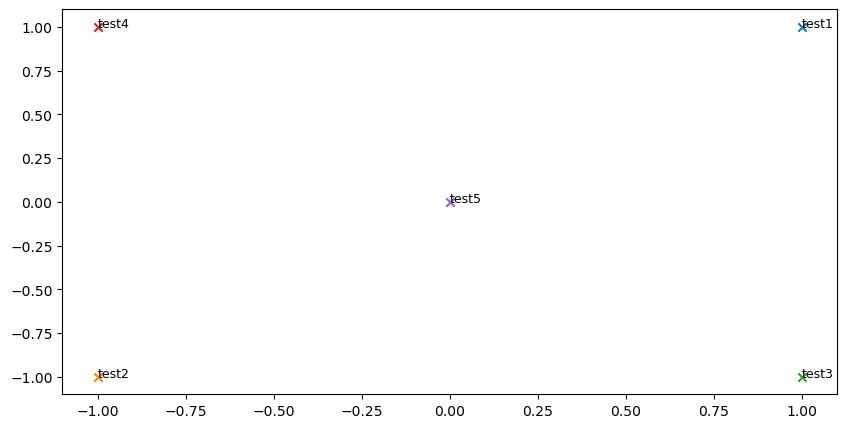

--------------------------------------------------------------------------------


In [11]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness.
# The plot produced should look like the included file question_1.4_test.png 
# ---------------------

print ("-" * 80)
print ("Outputted Plot:")

M_reduced_plot_test = np.array([[1, 1], [-1, -1], [1, -1], [-1, 1], [0, 0]])
word2ind_plot_test = {'test1': 0, 'test2': 1, 'test3': 2, 'test4': 3, 'test5': 4}
words = ['test1', 'test2', 'test3', 'test4', 'test5']
plot_embeddings(M_reduced_plot_test, word2ind_plot_test, words)

print ("-" * 80)

### Question 1.5: Co-Occurrence Plot Analysis [written] (3 points)

Now we will put together all the parts you have written! We will compute the co-occurrence matrix with fixed window of 4 (the default window size), over the Large Movie Review corpus. Then we will use TruncatedSVD to compute 2-dimensional embeddings of each word. TruncatedSVD returns U\*S, so we need to normalize the returned vectors, so that all the vectors will appear around the unit circle (therefore closeness is directional closeness). **Note**: The line of code below that does the normalizing uses the NumPy concept of *broadcasting*. If you don't know about broadcasting, check out
[Computation on Arrays: Broadcasting by Jake VanderPlas](https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html).

Run the below cell to produce the plot. It can take up to a few minutes to run.

### 问题 1.5：共现图分析 [书面]（3分）

现在，我们将把您所写的所有部分整合起来！我们将使用固定窗口大小为4（默认窗口大小）的共现矩阵，对大型电影评论语料库进行计算。然后，我们将使用TruncatedSVD来计算每个单词的二维嵌入。TruncatedSVD返回U\*S，因此我们需要对返回的向量进行归一化，使得所有向量都出现在单位圆周围（因此接近性是方向上的接近性）。**注意**：以下执行归一化的代码行使用了NumPy的广播概念。如果您不了解广播，可以查看[数组上的计算：广播 - Jake VanderPlas](https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html)。

运行以下单元格以生成图表。运行可能需要几分钟时间。

Running Truncated SVD over 5880 words...
Done.


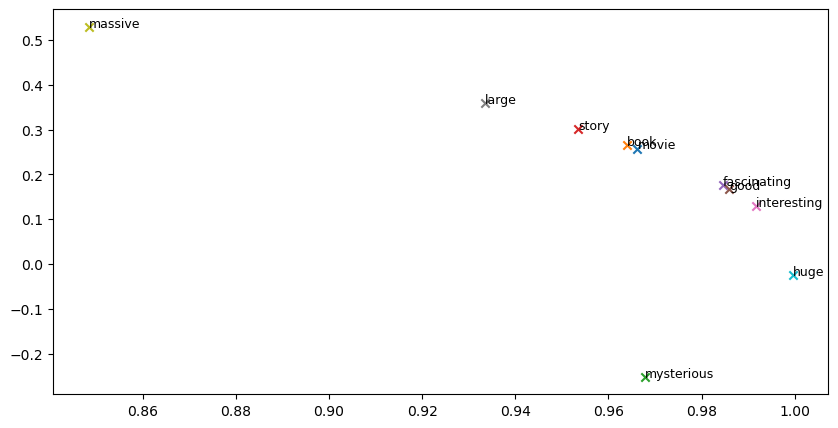

In [12]:
# -----------------------------
# Run This Cell to Produce Your Plot
# ------------------------------
imdb_corpus = read_corpus()
M_co_occurrence, word2ind_co_occurrence = compute_co_occurrence_matrix(imdb_corpus)
M_reduced_co_occurrence = reduce_to_k_dim(M_co_occurrence, k=2)

# Rescale (normalize) the rows to make them each of unit-length
M_lengths = np.linalg.norm(M_reduced_co_occurrence, axis=1)
M_normalized = M_reduced_co_occurrence / M_lengths[:, np.newaxis] # broadcasting

words = ['movie', 'book', 'mysterious', 'story', 'fascinating', 'good', 'interesting', 'large', 'massive', 'huge']

plot_embeddings(M_normalized, word2ind_co_occurrence, words)

**Verify that your figure matches "question_1.5.png" in the assignment zip. If not, use the figure in "question_1.5.png" to answer the next two questions.**

**请核实您的图形是否与作业压缩包中的 "question_1.5.png" 匹配。如果不匹配，请使用 "question_1.5.png" 中的图形来回答接下来的两个问题。**

a. Find at least two groups of words that cluster together in 2-dimensional embedding space. Give an explanation for each cluster you observe.

book,movie;fasnating,good.


b. What doesn't cluster together that you might think should have? Describe at least two examples.

large,massive;huge,massive

## Part 2: Prediction-Based Word Vectors (15 points)

As discussed in class, more recently prediction-based word vectors have demonstrated better performance, such as word2vec and GloVe (which also utilizes the benefit of counts). Here, we shall explore the embeddings produced by GloVe. Please revisit the class notes and lecture slides for more details on the word2vec and GloVe algorithms. If you're feeling adventurous, challenge yourself and try reading [GloVe's original paper](https://nlp.stanford.edu/pubs/glove.pdf).

Then run the following cells to load the GloVe vectors into memory. **Note**: If this is your first time to run these cells, i.e. download the embedding model, it will take a couple minutes to run. If you've run these cells before, rerunning them will load the model without redownloading it, which will take about 1 to 2 minutes.

## 第2部分：基于预测的词向量（15分）

正如课堂上所讨论的，近年来基于预测的词向量展现出更好的性能，例如word2vec和GloVe（也利用了计数的优势）。在这里，我们将探索由GloVe产生的嵌入。请重新阅读课堂笔记和讲义，以获取更多关于word2vec和GloVe算法的细节。如果你喜欢挑战，可以尝试阅读[GloVe的原始论文](https://nlp.stanford.edu/pubs/glove.pdf)。

然后运行以下单元格以将GloVe向量加载到内存中。**注意**：如果你是第一次运行这些单元格，即下载嵌入模型，将需要几分钟的时间。如果你之前已经运行过这些单元格，重新运行它们将不会重新下载模型，这大约需要1到2分钟。

In [13]:
from gensim.models import KeyedVectors
import os

def load_embedding_model():
    """ Load GloVe Vectors
        Return:
            wv_from_bin: All 400000 embeddings, each length 200
    """
    # 修改这里：指定你刚才下载并解压的 txt 文件路径
    # 如果文件在当前目录下，直接写文件名；如果在子目录，写 'path/to/glove.6B.200d.txt'
    glove_file = "glove.6B.200d.txt" 
    
    print("Loading GloVe model from local file...")
    
    # 关键点：
    # 1. binary=False: 因为这是 txt 文本文件
    # 2. no_header=True: GloVe 的原始格式没有第一行的统计信息(行数 维度)，必须加这个参数
    wv_from_bin = KeyedVectors.load_word2vec_format(glove_file, binary=False, no_header=True)
    
    print("Loaded vocab size %i" % len(wv_from_bin.index_to_key))
    return wv_from_bin

# 运行加载
wv_from_bin = load_embedding_model()

Loading GloVe model from local file...
Loaded vocab size 400000


In [44]:

def load_embedding_model():
    """ Load GloVe Vectors
        Return:
            wv_from_bin: All 400000 embeddings, each length 200
    """
    import gensim.downloader as api
    wv_from_bin = api.load("glove-wiki-gigaword-200")
    print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))
    return wv_from_bin
wv_from_bin = load_embedding_model()

URLError: <urlopen error [WinError 10054] 远程主机强迫关闭了一个现有的连接。>

#### Note: If you are receiving a "reset by peer" error, rerun the cell to restart the download. 

### Reducing dimensionality of Word Embeddings
Let's directly compare the GloVe embeddings to those of the co-occurrence matrix. In order to avoid running out of memory, we will work with a sample of 40000 GloVe vectors instead.
Run the following cells to:

1. Put 40000 Glove vectors into a matrix M
2. Run `reduce_to_k_dim` (your Truncated SVD function) to reduce the vectors from 200-dimensional to 2-dimensional.

### 降低词嵌入的维度
让我们直接比较GloVe嵌入和共现矩阵的嵌入。为了避免内存不足，我们将使用40000个GloVe向量的样本进行操作。
运行以下单元格以执行以下操作：

1. 将40000个GloVe向量放入矩阵M中
2. 运行`reduce_to_k_dim`（你的截断奇异值分解函数），将向量从200维降低到2维。

In [14]:
def get_matrix_of_vectors(wv_from_bin, required_words):
    """ Put the GloVe vectors into a matrix M.
        Param:
            wv_from_bin: KeyedVectors object; the 400000 GloVe vectors loaded from file
        Return:
            M: numpy matrix shape (num words, 200) containing the vectors
            word2ind: dictionary mapping each word to its row number in M
    """
    import random
    words = list(wv_from_bin.index_to_key)
    print("Shuffling words ...")
    random.seed(225)
    random.shuffle(words)
    print("Putting %i words into word2ind and matrix M..." % len(words))
    word2ind = {}
    M = []
    curInd = 0
    for w in words:
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    for w in required_words:
        if w in words:
            continue
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    M = np.stack(M)
    print("Done.")
    return M, word2ind

In [15]:
# -----------------------------------------------------------------
# Run Cell to Reduce 200-Dimensional Word Embeddings to k Dimensions
# Note: This should be quick to run
# -----------------------------------------------------------------
M, word2ind = get_matrix_of_vectors(wv_from_bin, words)
M_reduced = reduce_to_k_dim(M, k=2)

# Rescale (normalize) the rows to make them each of unit-length
M_lengths = np.linalg.norm(M_reduced, axis=1)
M_reduced_normalized = M_reduced / M_lengths[:, np.newaxis] # broadcasting

Shuffling words ...
Putting 400000 words into word2ind and matrix M...
Done.
Running Truncated SVD over 400000 words...
Done.


**Note: If you are receiving out of memory issues on your local machine, try closing other applications to free more memory on your device. You may want to try restarting your machine so that you can free up extra memory. Then immediately run the jupyter notebook and see if you can load the word vectors properly. If you still have problems with loading the embeddings onto your local machine after this, please go to office hours or contact course staff.**

**注意：如果您在本地机器上遇到内存不足的问题，请尝试关闭其他应用程序以释放设备上的更多内存。您可能需要重启机器以释放额外的内存。然后立即运行jupyter笔记本，看是否能正确加载词向量。如果在执行了以上操作后您仍然在本地机器上加载嵌入有问题，请前往办公时间或联系课程工作人员。**

### Question 2.1: GloVe Plot Analysis [written] (3 points)

Run the cell below to plot the 2D GloVe embeddings for `['movie', 'book', 'mysterious', 'story', 'fascinating', 'good', 'interesting', 'large', 'massive', 'huge']`.

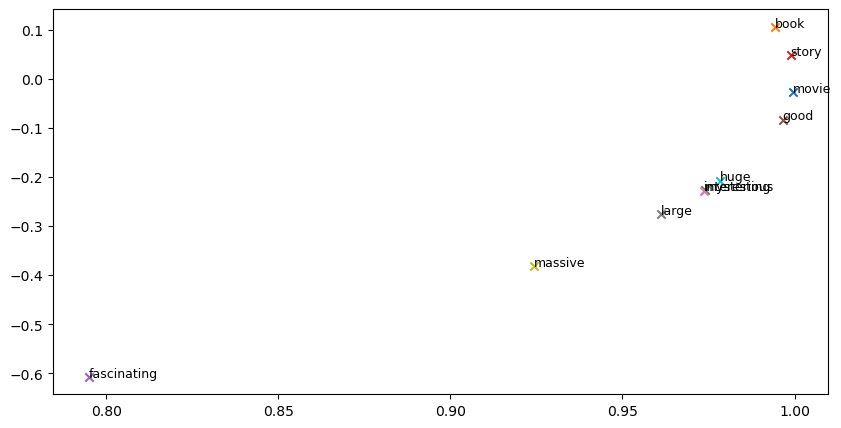

In [16]:
words = ['movie', 'book', 'mysterious', 'story', 'fascinating', 'good', 'interesting', 'large', 'massive', 'huge']

plot_embeddings(M_reduced_normalized, word2ind, words)

**Verify that your figure matches "question_2.1.png" in the assignment zip. If not, use the figure in "question_2.1.png" (and the figure in "question_1.5.png", if applicable) to answer the next two questions.**

a. What is one way the plot is different from the one generated earlier from the co-occurrence matrix? What is one way it's similar?

a. 与之前从共现矩阵生成的情节相比，它们之间有一个不同之处和一个相似之处是什么？

都有语义聚类；glove图更紧密，清晰，

b. Why might the GloVe plot (question_2.1.png) differ from the plot generated earlier from the co-occurrence matrix (question_1.5.png)?

b. 为什么GloVe图（question_2.1.png）可能与之前从共现矩阵生成的图（question_1.5.png）有所不同？

使用的数据与生成矩阵的算法不同

### Cosine Similarity
Now that we have word vectors, we need a way to quantify the similarity between individual words, according to these vectors. One such metric is cosine-similarity. We will be using this to find words that are "close" and "far" from one another.

We can think of n-dimensional vectors as points in n-dimensional space. If we take this perspective [L1](http://mathworld.wolfram.com/L1-Norm.html) and [L2](http://mathworld.wolfram.com/L2-Norm.html) Distances help quantify the amount of space "we must travel" to get between these two points. Another approach is to examine the angle between two vectors. From trigonometry we know that:

<img src="./imgs/inner_product.png" width=20% style="float: center;"></img>

Instead of computing the actual angle, we can leave the similarity in terms of $similarity = cos(\Theta)$. Formally the [Cosine Similarity](https://en.wikipedia.org/wiki/Cosine_similarity) $s$ between two vectors $p$ and $q$ is defined as:

$$s = \frac{p \cdot q}{||p|| ||q||}, \textrm{ where } s \in [-1, 1] $$ 

### 余弦相似度
现在我们有了词向量，需要一种方法来量化这些向量中单个词之间的相似度。其中一个这样的指标就是余弦相似度。我们将使用它来找出彼此“接近”和“远离”的词。

我们可以将n维向量想象成n维空间中的点。如果我们采取这种观点，[L1](http://mathworld.wolfram.com/L1-Norm.html) 和 [L2](http://mathworld.wolfram.com/L2-Norm.html) 距离有助于量化“我们必须穿越”多少空间才能在这两点之间。另一种方法是检查两个向量之间的角度。从三角学我们知道：

![内积](./imgs/inner_product.png width=20% style="float: center;">)

我们不必计算实际的角，我们可以将相似度保留为 $similarity = cos(\Theta)$ 的形式。形式上，两个向量 $p$ 和 $q$ 之间的[余弦相似度](https://en.wikipedia.org/wiki/Cosine_similarity) $s$ 定义为：

$$s = \frac{p \cdot q}{||p|| ||q||}, \textrm{ 其中 } s \in [-1, 1] $$

### Question 2.2: Words with Multiple Meanings (1.5 points) [code + written] 
Polysemes and homonyms are words that have more than one meaning (see this [wiki page](https://en.wikipedia.org/wiki/Polysemy) to learn more about the difference between polysemes and homonyms ). Find a word with *at least two different meanings* such that the top-10 most similar words (according to cosine similarity) contain related words from *both* meanings. For example, "leaves" has both "go_away" and "a_structure_of_a_plant" meaning in the top 10, and "scoop" has both "handed_waffle_cone" and "lowdown". You will probably need to try several polysemous or homonymic words before you find one. 

Please state the word you discover and the multiple meanings that occur in the top 10. Why do you think many of the polysemous or homonymic words you tried didn't work (i.e. the top-10 most similar words only contain **one** of the meanings of the words)?

**Note**: You should use the `wv_from_bin.most_similar(word)` function to get the top 10 most similar words. This function ranks all other words in the vocabulary with respect to their cosine similarity to the given word. For further assistance, please check the __[GenSim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.FastTextKeyedVectors.most_similar)__.

### 问题 2.2：多义词（1.5 分）[代码 + 文字]
多义词和同音异义词是指具有多个意义的单词（更多信息请参阅[维基百科页面](https://en.wikipedia.org/wiki/Polysemy)，了解多义词和同音异义词之间的区别）。找到一个具有至少两个不同意义的单词，其前 10 个最相似单词（根据余弦相似度）包含来自这两个意义的相关单词。例如，“leaves”具有“go_away”和“a_structure_of_a_plant”的意义，在前 10 个最相似单词中，而“scoop”具有“handed_waffle_cone”和“lowdown”的意义。你可能需要尝试多个多义词或同音异义词才能找到合适的例子。

请说明你发现的单词及其在 top 10 中出现的多个意义。你认为为什么你尝试的许多多义词或同音异义词没有成功（即前 10 个最相似单词只包含单词的一个意义）？

**注意**：请使用 `wv_from_bin.most_similar(word)` 函数来获取前 10 个最相似单词。此函数根据给定单词与词汇表中所有其他单词的余弦相似度进行排名。如需进一步帮助，请参阅 __[GenSim 文档](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.FastTextKeyedVectors.most_similar)__。

In [17]:
# ------------------
# Write your implementation here.

wv_from_bin.most_similar('bear')
# ------------------

[('bears', 0.684942364692688),
 ('grizzly', 0.6034085154533386),
 ('wolf', 0.5907025337219238),
 ('stearns', 0.5704878568649292),
 ('lion', 0.5357851386070251),
 ('bearing', 0.5106834173202515),
 ('dog', 0.5077008605003357),
 ('big', 0.4913228452205658),
 ('bore', 0.4897792339324951),
 ('deer', 0.4877018630504608)]

grizzly与stearns

### Question 2.3: Synonyms & Antonyms (2 points) [code + written] 

When considering Cosine Similarity, it's often more convenient to think of Cosine Distance, which is simply 1 - Cosine Similarity.

Find three words $(w_1,w_2,w_3)$ where $w_1$ and $w_2$ are synonyms and $w_1$ and $w_3$ are antonyms, but Cosine Distance $(w_1,w_3) <$ Cosine Distance $(w_1,w_2)$. 

As an example, $w_1$="happy" is closer to $w_3$="sad" than to $w_2$="cheerful". Please find a different example that satisfies the above. Once you have found your example, please give a possible explanation for why this counter-intuitive result may have happened.

You should use the the `wv_from_bin.distance(w1, w2)` function here in order to compute the cosine distance between two words. Please see the __[GenSim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.FastTextKeyedVectors.distance)__ for further assistance.

### 问题 2.3：同义词与反义词（2 分）[代码 + 文字]

在考虑余弦相似度时，通常更方便将其视为余弦距离，它简单地是 1 减去余弦相似度。

找出三个词 $(w_1,w_2,w_3)$，其中 $w_1$ 和 $w_2$ 是同义词，$w_1$ 和 $w_3$ 是反义词，但余弦距离 $(w_1,w_3) <$ 余弦距离 $(w_1,w_2)$。

例如，$w_1$="happy"（快乐）比 $w_2$="cheerful"（高兴）更接近 $w_3$="sad"（悲伤）。请找到一个满足上述条件的不同例子。一旦找到这个例子，请给出可能的原因解释为什么会出现这种反直觉的结果。

您应该使用 `wv_from_bin.distance(w1, w2)` 函数来计算两个词之间的余弦距离。请参阅 __[GenSim 文档](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.FastTextKeyedVectors.distance)__ 以获得更多帮助。

In [19]:
# ------------------
# Write your implementation here.

print(wv_from_bin.distance('woman','lady'),wv_from_bin.distance('woman','man'))

# ------------------

0.48076022 0.24799138


woman 与 man 意思相反但使用场景相近，woman 与 lady 意思相近但使用场景不同

### Question 2.4: Analogies with Word Vectors [written] (1.5 points)
Word vectors have been shown to *sometimes* exhibit the ability to solve analogies. 

As an example, for the analogy "man : grandfather :: woman : x" (read: man is to grandfather as woman is to x), what is x?

In the cell below, we show you how to use word vectors to find x using the `most_similar` function from the __[GenSim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.KeyedVectors.most_similar)__. The function finds words that are most similar to the words in the `positive` list and most dissimilar from the words in the `negative` list (while omitting the input words, which are often the most similar; see [this paper](https://www.aclweb.org/anthology/N18-2039.pdf)). The answer to the analogy will have the highest cosine similarity (largest returned numerical value).

### 问题 2.4：与词向量相关的类比 [书面]（1.5 分）
词向量有时表现出解决类比问题的能力。

例如，对于类比 "man : grandfather :: woman : x"（读作：man 与 grandfather 的关系类似于 woman 与 x 的关系），x 是什么？

在下面的单元格中，我们展示了如何使用 `most_similar` 函数（来自 __[GenSim 文档](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.KeyedVectors.most_similar)__）利用词向量找到 x。该函数寻找与 `positive` 列表中的词语最相似的词语，并且与 `negative` 列表中的词语最不相似（同时排除输入词语，因为它们通常是最相似的；参见 [这篇论文](https://www.aclweb.org/anthology/N18-2039.pdf)）。类比问题的答案将具有最高的余弦相似度（返回的数值最大）。

In [20]:
# Run this cell to answer the analogy -- man : grandfather :: woman : x
pprint.pprint(wv_from_bin.most_similar(positive=['woman', 'grandfather'], negative=['man']))

[('grandmother', 0.7608445286750793),
 ('granddaughter', 0.7200807332992554),
 ('daughter', 0.7168302536010742),
 ('mother', 0.7151536345481873),
 ('niece', 0.7005682587623596),
 ('father', 0.6659888029098511),
 ('aunt', 0.6623408794403076),
 ('grandson', 0.6618767380714417),
 ('grandparents', 0.6446609497070312),
 ('wife', 0.6445354223251343)]


Let $m$, $g$, $w$, and $x$ denote the word vectors for `man`, `grandfather`, `woman`, and the answer, respectively. Using **only** vectors $m$, $g$, $w$, and the vector arithmetic operators $+$ and $-$ in your answer, what is the expression in which we are maximizing cosine similarity with $x$?

Hint: Recall that word vectors are simply multi-dimensional vectors that represent a word. It might help to draw out a 2D example using arbitrary locations of each vector. Where would `man` and `woman` lie in the coordinate plane relative to `grandfather` and the answer?

设 $m$、$g$、$w$ 和 $x$ 分别表示单词 "man"（男人）、"grandfather"（祖父）、"woman"（女人）和答案的词向量。使用 **仅** $m$、$g$、$w$ 和向量算术运算符 $+$ 和 $-$，我们如何表达最大化与 $x$ 的余弦相似度的表达式？

提示：回想一下，词向量只是表示一个词的多维向量。可能有助于绘制一个二维示例，使用每个向量的任意位置。在坐标平面中，"man" 和 "woman" 相对于 "grandfather" 和答案将位于何处？

$ g-m+w$

### Question 2.5: Finding Analogies [code + written]  (1.5 points)
a. For the previous example, it's clear that "grandmother" completes the analogy. But give an intuitive explanation as to why the `most_similar` function gives us words like "granddaughter", "daughter", or "mother?

### 问题 2.5：寻找类比 [代码 + 文字] （1.5 分）
a. 对于上一个例子，显然“grandmother”（祖母）完成了这个类比。但请给出一个直观的解释来说明为什么 `most_similar` 函数给出了“granddaughter”（孙女）、“daughter”（女儿）或“mother”（母亲）这样的单词？

都是具有代际差的异性

b. Find an example of analogy that holds according to these vectors (i.e. the intended word is ranked top). In your solution please state the full analogy in the form x:y :: a:b. If you believe the analogy is complicated, explain why the analogy holds in one or two sentences.

**Note**: You may have to try many analogies to find one that works!

b. 找到符合这些向量（即预期单词排名最高）的类比示例（即以 x:y :: a:b 的形式陈述完整的类比）。在您的解决方案中，请说明完整的类比，并如果认为类比复杂，请用一句话或两句话解释类比为何成立。

**注意**：您可能需要尝试许多类比才能找到一个合适的！

In [24]:
# For example: x, y, a, b = ("", "", "", "")
# ------------------
# Write your implementation here.

x, y, a, b = ("pig", "pork", "cow", "beef")
# ------------------

# Test the solution
assert wv_from_bin.most_similar(positive=[a, y], negative=[x])[0][0] == b

pork/beef is made of pig/cow

### Question 2.6: Incorrect Analogy [code + written] (1.5 points)
a. Below, we expect to see the intended analogy "hand : glove :: foot : **sock**", but we see an unexpected result instead. Give a potential reason as to why this particular analogy turned out the way it did?

### 问题 2.6：不正确的类比 [代码 + 书面] (1.5 分)
a. 下面，我们期望看到预期的类比 "手 : 手套 :: 脚 : **袜子**"，但结果却出人意料。给出一个可能导致这个特定类比结果的原因？

In [25]:
pprint.pprint(wv_from_bin.most_similar(positive=['foot', 'glove'], negative=['hand']))

[('45,000-square', 0.4922032058238983),
 ('15,000-square', 0.4649604558944702),
 ('10,000-square', 0.45447564125061035),
 ('6,000-square', 0.44975781440734863),
 ('3,500-square', 0.4441334009170532),
 ('700-square', 0.44257503747940063),
 ('50,000-square', 0.43563973903656006),
 ('3,000-square', 0.43486514687538147),
 ('30,000-square', 0.4330596923828125),
 ('footed', 0.43236875534057617)]


foot - hand 具有了计量单位的语义

b. Find another example of analogy that does *not* hold according to these vectors. In your solution, state the intended analogy in the form x:y :: a:b, and state the **incorrect** value of b according to the word vectors (in the previous example, this would be **'45,000-square'**).

b. 找到另一个不根据这些向量成立的类比示例。在你的解决方案中，以 x:y :: a:b 的形式陈述预期的类比，并说明根据词向量（在先前的例子中，这将是指 **'45,000-square'**）的 **不正确** 的 b 值。

In [28]:
# For example: x, y, a, b = ("", "", "", "")
# ------------------
# Write your implementation here.
x, y, a, b = ("boat", "water", "bus", "road")

# ------------------
pprint.pprint(wv_from_bin.most_similar(positive=[a, y], negative=[x]))
assert wv_from_bin.most_similar(positive=[a, y], negative=[x])[0][0] != b

[('electricity', 0.5340558290481567),
 ('buses', 0.5320359468460083),
 ('metro', 0.5227330327033997),
 ('rail', 0.5226054787635803),
 ('gas', 0.5143956542015076),
 ('transportation', 0.49480363726615906),
 ('transport', 0.47991493344306946),
 ('areas', 0.4773302972316742),
 ('municipal', 0.47514355182647705),
 ('roads', 0.4749017357826233)]


#### <font color="red">Write your answer here.</font>

### Question 2.7: Guided Analysis of Bias in Word Vectors [written] (1 point)

It's important to be cognizant of the biases (gender, race, sexual orientation etc.) implicit in our word embeddings. Bias can be dangerous because it can reinforce stereotypes through applications that employ these models.

Run the cell below, to examine (a) which terms are most similar to "man" and "profession" and most dissimilar to "woman" and (b) which terms are most similar to "woman" and "profession" and most dissimilar to "man". Point out the difference between the list of female-associated words and the list of male-associated words, and explain how it is reflecting gender bias.

### 问题 2.7：词向量中偏见的指导分析 [书面]（1分）

了解我们词向量中隐含的偏见（性别、种族、性取向等）是非常重要的。偏见可能很危险，因为它可能会通过使用这些模型的应用来强化刻板印象。

运行下面的单元格，以检查（a）哪些词与“man”（男人）和“profession”（职业）最相似，与“woman”（女人）最不相似；（b）哪些词与“woman”（女人）和“profession”（职业）最相似，与“man”（男人）最不相似。指出女性相关词汇列表和男性相关词汇列表之间的差异，并解释它如何反映性别偏见。

In [29]:
# Run this cell
# Here `positive` indicates the list of words to be similar to and `negative` indicates the list of words to be
# most dissimilar from.

pprint.pprint(wv_from_bin.most_similar(positive=['man', 'profession'], negative=['woman']))
print()
pprint.pprint(wv_from_bin.most_similar(positive=['woman', 'profession'], negative=['man']))

[('reputation', 0.5250176787376404),
 ('professions', 0.5178037881851196),
 ('skill', 0.49046966433525085),
 ('skills', 0.49005505442619324),
 ('ethic', 0.4897659420967102),
 ('business', 0.487585186958313),
 ('respected', 0.4859202802181244),
 ('practice', 0.48210468888282776),
 ('regarded', 0.4778572916984558),
 ('life', 0.4760662019252777)]

[('professions', 0.5957457423210144),
 ('practitioner', 0.4988412857055664),
 ('teaching', 0.48292139172554016),
 ('nursing', 0.48211804032325745),
 ('vocation', 0.4788965880870819),
 ('teacher', 0.47160351276397705),
 ('practicing', 0.46937811374664307),
 ('educator', 0.46524322032928467),
 ('physicians', 0.46289944648742676),
 ('professionals', 0.46013936400413513)]


这反映了男人更擅长技巧，商业的职业，而女性跟擅长教育，护理的职业的性别偏见

### Question 2.8: Independent Analysis of Bias in Word Vectors [code + written]  (1 point)

Use the `most_similar` function to find another pair of analogies that demonstrates some bias is exhibited by the vectors. Please briefly explain the example of bias that you discover.

### 问题 2.8：对词向量中偏差的独立分析 [代码 + 文字]（1 分）

使用 `most_similar` 函数找到另一对类比，以展示向量中存在一些偏差。请简要解释你所发现的偏差示例。

In [34]:
# ------------------
# Write your implementation here.
a,b,x='japanese', 'chinese','disposition'
pprint.pprint(wv_from_bin.most_similar(positive=[a, x], negative=[b]))
print()
pprint.pprint(wv_from_bin.most_similar(positive=[b, x], negative=[a]))
# ------------------

[('dispositions', 0.5474783182144165),
 ('demeanor', 0.38813620805740356),
 ('demeanour', 0.38236555457115173),
 ('predisposition', 0.3691602349281311),
 ('capitulation', 0.36012721061706543),
 ('spendthrift', 0.3570941686630249),
 ('forgiving', 0.3567229211330414),
 ('sullen', 0.35571354627609253),
 ('antisocial', 0.3555956780910492),
 ('benign', 0.35238760709762573)]

[('temperament', 0.47027313709259033),
 ('manner', 0.41082724928855896),
 ('attitude', 0.39271116256713867),
 ('regards', 0.39162737131118774),
 ('dignified', 0.38644927740097046),
 ('amiable', 0.38490623235702515),
 ('thereof', 0.3842219412326813),
 ('dispositions', 0.3748001456260681),
 ('intellectual', 0.37084391713142395),
 ('cheerful', 0.3611708879470825)]


[
  ('dispositions', 0.5474783182144165) - 性格倾向，
  ('demeanor', 0.38813620805740356) - 行为举止，
  ('demeanour', 0.38236555457115173) - 行为举止（英式英语），
  ('predisposition', 0.3691602349281311) - 倾向，
  ('capitulation', 0.36012721061706543) - 投降，
  ('spendthrift', 0.3570941686630249) - 奢侈浪费的，
  ('forgiving', 0.3567229211330414) - 宽容的，
  ('sullen', 0.35571354627609253) - 阴沉的，
  ('antisocial', 0.3555956780910492) - 反社会的，
  ('benign', 0.35238760709762573) - 和善的
]

[
  ('temperament', 0.47027313709259033) - 性情，
  ('manner', 0.41082724928855896) - 方式，
  ('attitude', 0.39271116256713867) - 态度，
  ('regards', 0.39162737131118774) - 关于，
  ('dignified', 0.38644927740097046) - 庄重的，
  ('amiable', 0.38490623235702515) - 和蔼可亲的，
  ('thereof', 0.3842219412326813) - 关于此，
  ('dispositions', 0.3748001456260681) - 性格倾向，
  ('intellectual', 0.37084391713142395) - 智力的，
  ('cheerful', 0.3611708879470825) - 快乐的
]

辱日了

In [41]:
# ------------------
# Write your implementation here.
a,b,x='america', 'china','leader'
pprint.pprint(wv_from_bin.most_similar(positive=[a, x], negative=[b],topn=50))
print()
pprint.pprint(wv_from_bin.most_similar(positive=[b, x], negative=[a],topn=50))
# ------------------

[('leaders', 0.48302972316741943),
 ('leadership', 0.47451555728912354),
 ('american', 0.46401146054267883),
 ('charismatic', 0.44518473744392395),
 ('movement', 0.44282612204551697),
 ('nelson', 0.43437373638153076),
 ('radical', 0.43322643637657166),
 ('rev.', 0.4286838471889496),
 ('pastor', 0.4223176836967468),
 ('conservative', 0.4191409647464752),
 ('preacher', 0.4189119040966034),
 ('cleric', 0.4186570346355438),
 ('socialist', 0.41607576608657837),
 ('leftist', 0.41189923882484436),
 ('nation', 0.40866971015930176),
 ('politician', 0.4078153371810913),
 ('liberal', 0.4063417315483093),
 ('firebrand', 0.4059961140155792),
 ('coalition', 0.40512707829475403),
 ('party', 0.40425944328308105),
 ('hero', 0.40021011233329773),
 ('whose', 0.3989350497722626),
 ('led', 0.3986338973045349),
 ('militant', 0.39510107040405273),
 ('muqtada', 0.3940155804157257),
 ('former', 0.3937579393386841),
 ('_', 0.39115798473358154),
 ('longtime', 0.39103591442108154),
 ('``', 0.3904682993888855),
 (

### Question 2.9: Thinking About Bias [written] (2 points)

a. Give one possible explanation of how bias gets into the word vectors. Your explanation should be focused on word vectors, as opposed to bias in other AI systems (e.g., ChatGPT). You can use specific historical examples to back up your explanations if necessary.

### 问题 2.9：关于偏差的思考 [书面]（2分）
a. 提供一个可能的解释，说明偏差是如何进入词向量的。你的解释应专注于词向量，而不是其他AI系统中的偏差（例如ChatGPT）。如有必要，你可以使用具体的历史例子来支持你的解释。

在训练时使用了具有歧视性的数据

b. What is one possible method you can use to mitigate bias exhibited by word vectors? Briefly explain the method and what the goal of the method was.

b. 减少词向量所表现出的偏见的可能方法之一是什么？简要解释该方法及其目标。

一种可能的方法是使用对抗性训练来减少词向量的偏见。对抗性训练的目标是通过向词向量中添加微小但精心设计的扰动来训练模型，从而使模型能够学习到更加公平和客观的表示。这种方法旨在使模型能够识别并减少与性别、种族、年龄等社会特征相关的偏见，从而使词向量在语义上更加公正。

# <font color="blue"> Submission Instructions</font>

1. Click the Save button at the top of the Jupyter Notebook.
2. Select Edit -> Clear Outputs of All Cells. This will clear all the outputs from all cells (but will keep the content of all cells). 
2. Select Run -> Run All Cells. This will run all the cells in order, and will take several minutes.
3. Once you've rerun everything, select File -> Save and Export Notebook as -> PDF (If you see errors like <font color="red">"nbconvert failed: Pandoc wasn't found"</font>, you can first save it as HTML). Select File -> Save and Export Notebook as -> HTML. This will save the notebook as an HTML file on your computer. Open the downloaded HTML file in your web browser. In the browser, press Ctrl + P (Windows/Linux) or Cmd + P (Mac) to open the print dialog. In the print dialog, change the destination to Save as PDF and click Save. <font color='blue'> Make sure all your solutions especially the coding parts are displayed in the pdf</font>, it's okay if the provided codes get cut off because lines are not wrapped in code cells.
4. Look at the PDF file and make sure all your solutions are there, displayed correctly. The PDF is the only thing your graders will see!
5. Submit your PDF on Gradescope.